In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.datasets import CIFAR10
import numpy as np
from torch.utils.data import random_split, DataLoader
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# Setting up CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
train_val = [0.75, 0.25]
batch_size = 64
l_r = 1e-3
epochs = 75
input_channels = 3
no_of_classes = 10

# Data Preprocessing

In [4]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5),
])
test_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, ), (0.5,))])

train_data = CIFAR10(root="./dataset", train=True, download=True, transform=train_transform)
test_data = CIFAR10(root="./dataset", train=False, download=True, transform=test_transform)

train_data, val_data = random_split(train_data, train_val)

100%|████████████████████████████████████████| 170M/170M [38:33<00:00, 73.7kB/s]


In [5]:
train_dl = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_dl = DataLoader(test_data, batch_size=batch_size)
val_dl = DataLoader(val_data, batch_size=batch_size)

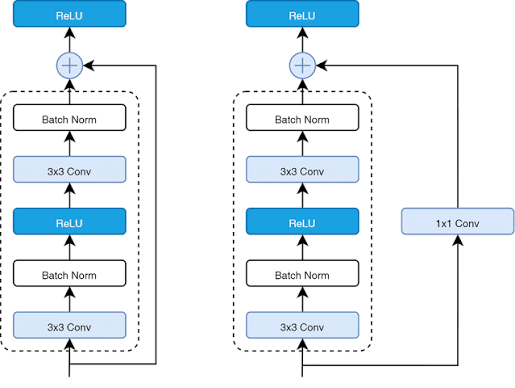

In [6]:
class ResNetBlock(nn.Module):
    def __init__(self, input_size, output_size, strides=1, conv1x1=False):
        super().__init__()
        self.conv1x1 = conv1x1
        
        self.conv1 = nn.Conv2d(input_size, output_size, kernel_size=3, padding=1, stride=strides)
        self.batchnorm1 = nn.BatchNorm2d(output_size)
        self.relu = nn.ReLU()
        
        self.conv2 = nn.Conv2d(output_size, output_size, kernel_size=3, padding=1)
        self.batchnorm2 = nn.BatchNorm2d(output_size)
        
        if conv1x1:
            self.conv3 = nn.Conv2d(input_size, output_size, kernel_size=1, stride=strides) 

    def forward(self, X): 
        Y = self.conv1(X)
        Y = self.batchnorm1(Y)
        Y = self.relu(Y)
        
        Y = self.conv2(Y)
        Y = self.batchnorm2(Y)
        
        if self.conv1x1:
            # For Projection Block
            X = self.conv3(X)
            
        Y += X
        return self.relu(Y) 

In [7]:
class ResNetStage(nn.Module):
    # Contains multiple ResNetBlocks
    def __init__(self, input_size, output_size, no_of_blocks, first_stage=False):
        super().__init__()
        blocks =[]

        if first_stage:
            blocks.append(ResNetBlock(input_size, output_size, strides=1))
        else:
            blocks.append(ResNetBlock(input_size, output_size, strides=2, conv1x1=True))
            
        for _ in range(no_of_blocks-1):
            blocks.append(ResNetBlock(output_size, output_size))

        self.stage = nn.Sequential(*blocks)

    def forward(self, X):
        return self.stage(X)

In [8]:
class ResNet(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        self.stem = nn.Sequential(nn.Conv2d(input_size, 32, kernel_size=3), nn.BatchNorm2d(32))

        stages = []
        
        stages.append(ResNetStage(32, 32, 3, True))
        stages.append(ResNetStage(32, 64, 3))
        stages.append(ResNetStage(64, 128, 3))
        stages.append(ResNetStage(128, 256, 1))

        self.stages = nn.Sequential(*stages)

        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.dropout = nn.Dropout(0.2)
        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(nn.Linear(256, 10))

    def forward(self, X):
        X = self.stem(X)
        X = self.stages(X)
        X = self.gap(X)
        X = self.dropout(X)
        X = self.flatten(X)
        Y = self.fc(X)

        return Y
        

In [9]:
model = ResNet(input_channels, no_of_classes).to(device)
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=l_r, 
    weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()

In [10]:
def validate_model(model, dl, criterion):
    running_loss = 0
    model.eval()
    running_loss = 0
    crt_pred = 0
    preds = 0
    
    with torch.no_grad():
        for X, y in dl:
            X = X.to(device)
            y = y.to(device)
    
            y_hat = model(X)
            loss = criterion(y_hat, y)
    
            running_loss += loss.item()
            out = torch.argmax(y_hat, dim=1)
            crt_pred += (out == y).sum().item()
            preds += y.size(0)

    return running_loss/len(dl), crt_pred / preds

In [11]:
def evaluate_classifier(model, dataloader):
    class_names = [
        "airplane",
        "automobile",
        "bird",
        "cat",
        "deer",
        "dog",
        "frog",
        "horse",
        "ship",
        "truck"
    ]
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Classification Report
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)

    print("\n====== Classification Report ======\n")
    print(report)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    fig, ax = plt.subplots(figsize=(10, 10))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

    plt.title("Confusion Matrix")
    plt.xticks(rotation=45)
    plt.show()


In [12]:
def train_model(dl, epochs, model, optimizer, loss_fn, val_dl):
    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []
    
    for epoch in range(epochs):
        model.train()
        
        running_loss = 0
        crt_pred = 0
        preds = 0

        for X, y in dl:
            X = X.to(device)
            y = y.to(device)
            
            y_hat = model(X)
            loss = loss_fn(y_hat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            out = torch.argmax(y_hat, dim=1)
            crt_pred += (out == y).sum().item()
            preds += y.size(0)

        val_loss, val_acc = validate_model(model, val_dl, loss_fn)
        
        train_losses.append(running_loss / len(dl))
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        train_accs.append(crt_pred / preds)
        
        
        print(
            f"Epoch {epoch+1} | "
            f"Loss: {running_loss / len(dl):.4f} | "
            f"Accuracy: {crt_pred / preds:.4f} | "
            f"Validation Accuracy : {val_acc:.4f} |"
            f"Validation Loss : {val_loss}"
        )
    return train_accs, val_accs, train_losses, val_losses

In [13]:
def plot_curves(train_acc, val_acc, train_loss, val_loss):
    epochs = range(1, len(train_acc) + 1)

    # Accuracy Plot
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_acc, label="Train Accuracy", linewidth=2)
    plt.plot(epochs, val_acc, label="Validation Accuracy", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Loss Plot
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, label="Train Loss", linewidth=2)
    plt.plot(epochs, val_loss, label="Validation Loss", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [14]:
train_Accs, val_Accs, train_Losses, val_Losses = train_model(train_dl, epochs, model, optimizer, criterion, val_dl)

Epoch 1 | Loss: 1.5115 | Accuracy: 0.4379 | Validation Accuracy : 0.5614 |Validation Loss : 1.2192354311748428
Epoch 2 | Loss: 1.1074 | Accuracy: 0.6004 | Validation Accuracy : 0.6188 |Validation Loss : 1.0836720913648605
Epoch 3 | Loss: 0.9312 | Accuracy: 0.6720 | Validation Accuracy : 0.6860 |Validation Loss : 0.8762671117271695
Epoch 4 | Loss: 0.8049 | Accuracy: 0.7198 | Validation Accuracy : 0.7366 |Validation Loss : 0.7655725688958654
Epoch 5 | Loss: 0.7133 | Accuracy: 0.7539 | Validation Accuracy : 0.7374 |Validation Loss : 0.7671870733706319
Epoch 6 | Loss: 0.6445 | Accuracy: 0.7777 | Validation Accuracy : 0.7614 |Validation Loss : 0.6988243755637383
Epoch 7 | Loss: 0.5887 | Accuracy: 0.7974 | Validation Accuracy : 0.7888 |Validation Loss : 0.6079267515819899
Epoch 8 | Loss: 0.5540 | Accuracy: 0.8105 | Validation Accuracy : 0.7872 |Validation Loss : 0.6098734450583555
Epoch 9 | Loss: 0.5166 | Accuracy: 0.8221 | Validation Accuracy : 0.8090 |Validation Loss : 0.5678411542761083
E

In [15]:
validate_model(model, val_dl, criterion)

(0.37327502584274935, 0.88248)


====== Classification Report ======

              precision    recall  f1-score   support

    airplane     0.8970    0.8970    0.8970      1000
  automobile     0.9669    0.9340    0.9502      1000
        bird     0.9141    0.7870    0.8458      1000
         cat     0.8440    0.7140    0.7736      1000
        deer     0.8466    0.9270    0.8850      1000
         dog     0.7897    0.8900    0.8369      1000
        frog     0.9170    0.9170    0.9170      1000
       horse     0.9025    0.9260    0.9141      1000
        ship     0.9172    0.9410    0.9289      1000
       truck     0.9117    0.9600    0.9352      1000

    accuracy                         0.8893     10000
   macro avg     0.8907    0.8893    0.8884     10000
weighted avg     0.8907    0.8893    0.8884     10000



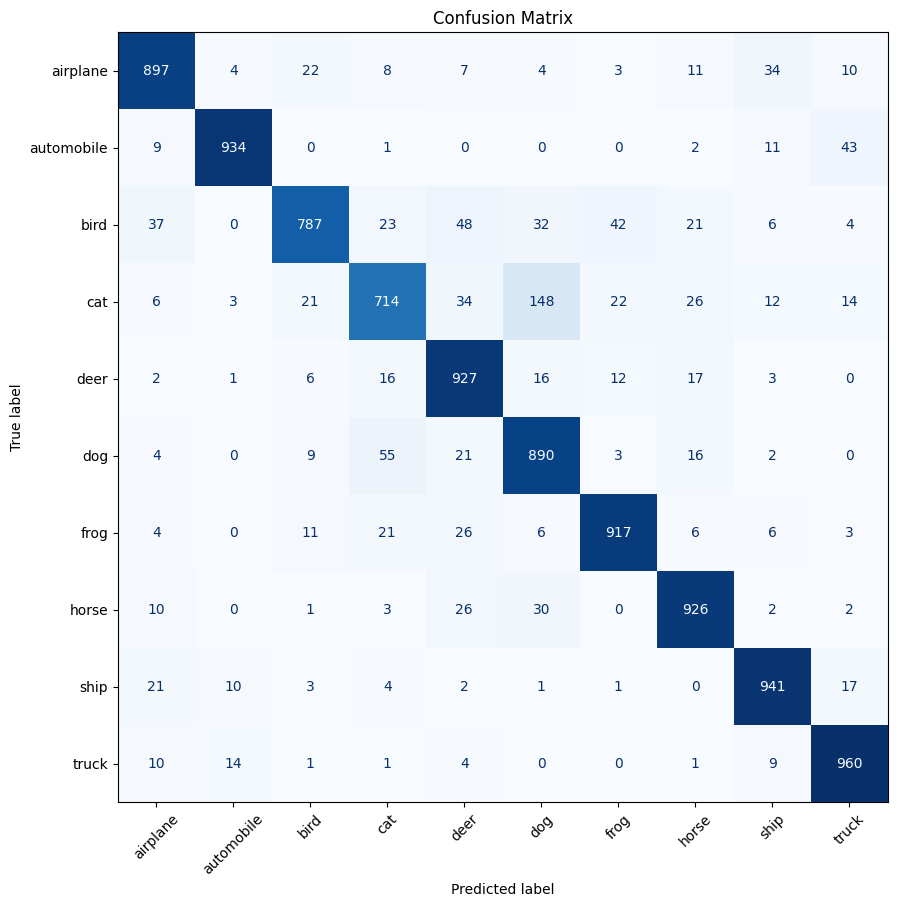

In [16]:
evaluate_classifier(model, test_dl)

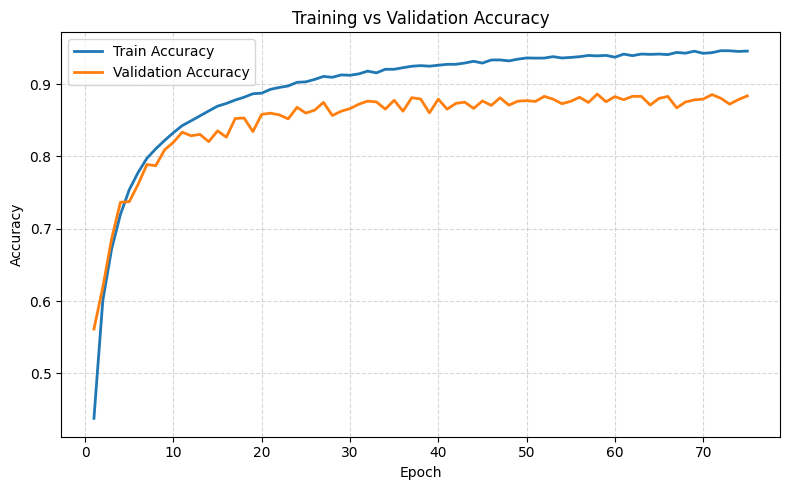

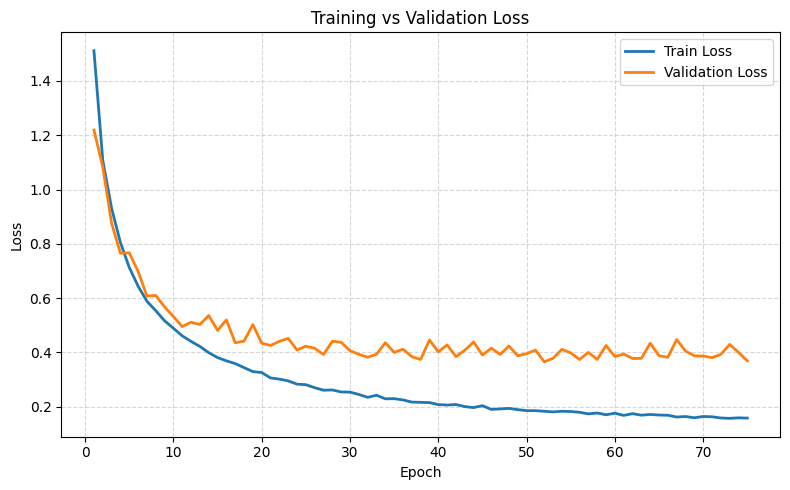

In [18]:
plot_curves(train_Accs, val_Accs, train_Losses, val_Losses)